<a href="https://colab.research.google.com/github/YardenGoraly/Mujoco_fun/blob/main/MuJoCo_fun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Initial setup, you shouldn't have to modify this code

# %pip install mujoco
# %pip install mediapy

import platform
import os
import subprocess
import mediapy as media

# Detect the operating system and configure GPU rendering accordingly.
if platform.system() == "Linux":
    # Assume Nvidia GPU is present.
    if subprocess.run("nvidia-smi", shell=True).returncode != 0:
        raise RuntimeError(
            "Cannot communicate with GPU. Make sure you are using a GPU runtime."
        )

    # Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
    NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
    if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
        with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
            f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")
    print("Setting environment variable for Nvidia GPU rendering (EGL).")
    os.environ["MUJOCO_GL"] = "egl"

elif platform.system() == "Darwin":
    # Assume running on macOS (Apple Silicon).
    print("Running on macOS. Setting environment variable for GPU rendering using GLFW.")
    os.environ["MUJOCO_GL"] = "glfw"

    media.set_ffmpeg("/opt/homebrew/bin/ffmpeg")
else:
    print("Unsupported platform. GPU rendering might not be configured correctly.")

# Check if MuJoCo installation was successful.
try:
    import mujoco as mj
    mj.MjModel.from_xml_string("<mujoco/>")
except Exception as e:
    raise RuntimeError(
        "Something went wrong during MuJoCo installation. Check the shell output above for more information."
    ) from e

print("MuJoCo installation successful.")

# Other imports and helper functions.
import time
import itertools
import numpy as np
np.set_printoptions(precision=3, suppress=True, linewidth=100)

# Graphics and plotting.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# On Linux, ensure ffmpeg is installed (this is not applicable on macOS).
if platform.system() == "Linux":
    !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)

%pip install -q mediapy
import mediapy as media

from IPython.display import clear_output
clear_output()


In [2]:
#More setup 
# %pip install robot_descriptions
# %pip install dm_control

from robot_descriptions import panda_mj_description
from IPython.display import HTML
from robot_descriptions.loaders.mujoco import load_robot_description
from dm_control import mjcf
import dm_control
import PIL.Image


def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())


In [3]:
# Get XML for Sawyer, hand, and ball
ball_xml = """
<mujoco model="ball">
    <worldbody>
        <body name="ball_body" pos="1.0 -0.2 0.95">
            <geom name="ball_geom" mass="0.01" friction="1.5" type="sphere" size="0.05" rgba="1 0 0 1"
                  solref="0.06 1" solimp="0.9 0.95 0.003 0.5 2"/>
        </body>
    </worldbody>
</mujoco>
"""

table_xml = """
<mujoco model="table">
    <worldbody>
        <body name="table_body" pos="1.0 -0.2 0.45">
            <geom name="table_geom" mass="200000" friction="0.8" type="box" solref="0.01 0.5" size="0.3 0.6 0.45" rgba="0.798 0.71 0.469 1"/>
        </body>
    </worldbody>
</mujoco>
"""

hand_path = "mujoco_menagerie/wonik_allegro/right_hand.xml"
sawyer_path = "mujoco_menagerie/rethink_robotics_sawyer/sawyer.xml"

In [4]:
# Define Models
hand_model = mjcf.from_path(hand_path)
sawyer_model = mjcf.from_path(sawyer_path)
ball_model = mjcf.from_xml_string(ball_xml)
table_model = mjcf.from_xml_string(table_xml)


# Fingertips in XML are not actually at the tip, so we add a body with an offset
ff_tip = hand_model.find('body', 'ff_tip')
ff_tip.add('body', name='ff_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'ff_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
mf_tip = hand_model.find('body', 'mf_tip')
mf_tip.add('body', name='mf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'mf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
rf_tip = hand_model.find('body', 'rf_tip')
rf_tip.add('body', name='rf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'rf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
th_tip = hand_model.find('body', 'th_tip')
th_tip.add('body', name='th_tip_rubber', pos=[0, 0, 0.044])
hand_model.find('body', 'th_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])

MJCF Element: <geom type="sphere" size="0.012" rgba="0 0 0 0"/>

In [5]:
# Attach hand to the Sawyer
arena = mjcf.RootElement()
sawyer_site = sawyer_model.find('site', 'attachment_site')
attachment_frame = arena.attach(ball_model) # added 7 DOF to qpos for ball
arena.attach(table_model)  # table does not have DOF
sawyer_site.attach(hand_model)  # Allegro hand is a child subtree of Sawyer
arena.attach(sawyer_model)  # attach Sawyer model (7 DOF) with Allegro subtree (16 DOF)

# Set up scene
sky = arena.asset.add('texture', type='skybox', builtin="gradient", rgb1=[0, .2, 1], 
                      rgb2="1 1 1", width=512, height=512)
chequered = arena.asset.add('texture', type='2d', builtin='checker', width=500,
                            height=500, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = arena.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[30, 30], reflectance=.1)
arena.worldbody.add('geom', type='plane', size=[10, 10, 10], material=grid)
for x in [-2, 2]:
  arena.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])
for y in [-2, 2]:
  arena.worldbody.add('light', pos=[-1, y, 3], dir=[1, -y, -2], attenuation=[3, 0, 0], castshadow=False)
arena.worldbody.add('camera', name='camera_1', pos=[-1, -1, 0.3], euler=[1.55, 2, 0])

# Add freejoint to ball so it can move freely
attachment_frame.add('joint', name='ball_joint', type='free', armature='5e-5')

# Extract ball elements to read attributes
ball_body = ball_model.find('body', 'ball_body')
ball_geom = ball_model.find('geom', 'ball_geom')

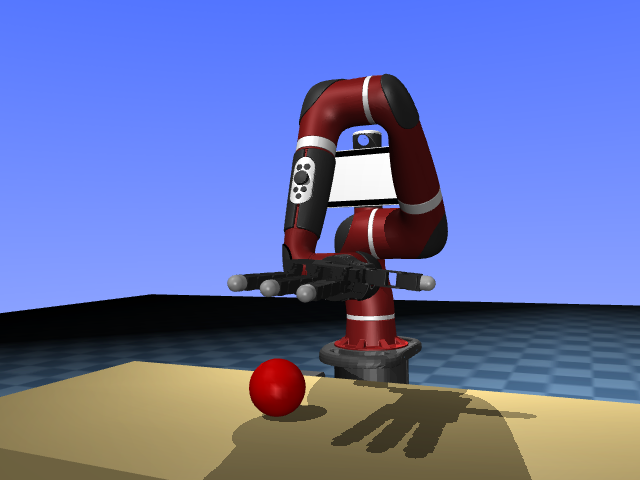

In [6]:
def set_camera_position(physics, camera_name, camera_position):
    camera_id = physics.model.name2id(camera_name, "camera")
    physics.named.model.cam_pos[camera_name] = camera_position
    return camera_id

def set_initial_configuration():
    initial_qpos = [0, 0, 0, 1.0, 0, 0, 0,          # Ball (pos+quat-scalar first) (workspace represent.)
                    0, -0.8, 0, 2, 0, -1.2, 3.2,    # Sawyer arm's palm (joint space)
                    0, 0, 0, 0,                     # ff finger (joint space)
                    0, 0, 0, 0,                     # mf finger (joint space)
                    0, 0, 0, 0,                     # rf finger (joint space)
                    0, 0, 0, 0]                     # thumb (joint space)
    
    # initial_qpos = [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,]
    
    physics.data.qpos[:] = initial_qpos

physics = mjcf.Physics.from_mjcf_model(arena)

# Init scene
camera_id1 = set_camera_position(physics, "camera_1", [1.9, 0.3, 1.2])
set_initial_configuration()

physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

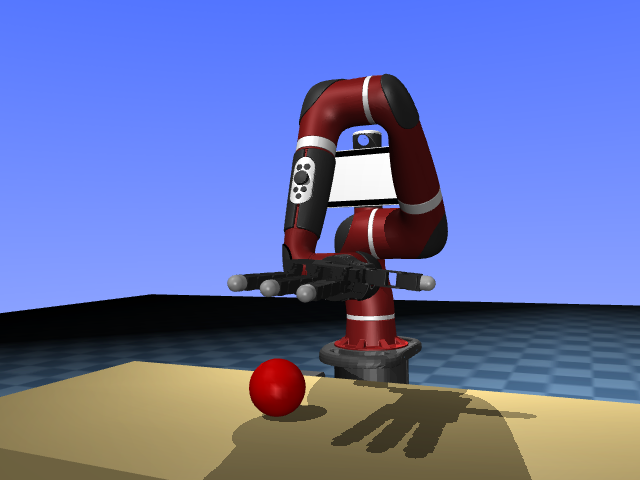

In [7]:
def set_camera_position(physics, camera_name, camera_position):
    camera_id = physics.model.name2id(camera_name, "camera")
    physics.named.model.cam_pos[camera_name] = camera_position
    return camera_id

def set_initial_configuration():
    initial_qpos = [0, 0, 0, 1, 0, 0, 0,            # Ball (pos+quat-scalar first) (workspace represent.)
                    0, -0.8, 0, 2, 0, -1.2, 3.2,    # Sawyer arm's palm (joint space)
                    0, 0, 0, 0,                     # ff finger (joint space)
                    0, 0, 0, 0,                     # mf finger (joint space)
                    0, 0, 0, 0,                     # rf finger (joint space)
                    0, 0, 0, 0]                     # thumb (joint space)
    
    # initial_qpos = [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,]
    
    physics.data.qpos[:] = initial_qpos

physics = mjcf.Physics.from_mjcf_model(arena)

# Init scene
camera_id1 = set_camera_position(physics, "camera_1", [1.9, 0.3, 1.2])
set_initial_configuration()

physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

In [8]:
print(physics.data.qpos) # print all the qpos
print(len(physics.data.qpos)) # print len of all the qpos
print(len(physics.data.qvel))

print()
print(physics.model.nq) # number of generalized coor. 
print(physics.model.nv)  # number of velocity
print()

# # print all the joint names
# for j in range(physics.model.njnt):
#     # notice: the use of `physics.model.ptr` the `.ptr` ensures the input is a mujoco model object
#     name = mj.mj_id2name(physics.model.ptr, mj.mjtObj.mjOBJ_JOINT, j)
#     print(j, name, physics.model.jnt_qposadr[j])

# print body id
print("palm body id is: ", physics.model.body('sawyer/allegro_right/palm').id)

# print the workspace config of a part using str id
print((physics.data.body('sawyer/allegro_right/palm').xpos))    # workspace position
print((physics.data.body('sawyer/allegro_right/palm').xquat))   # orientation in unit quaternion
print((physics.data.body('sawyer/allegro_right/palm').xmat).reshape(3,3))    # orientation in rotation matrix, q_ib
print(np.linalg.det((physics.data.body('sawyer/allegro_right/palm').xmat).reshape(3,3)))    # check deforientation in rotation matrix

# check the joint ranges
print(physics.model.jnt_range.shape)



[ 0.   0.   0.   1.   0.   0.   0.   0.  -0.8  0.   2.   0.  -1.2  3.2  0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
30
29

30
29

palm body id is:  17
[ 1.065 -0.1    1.141]
[ 0.706 -0.041  0.706 -0.041]
[[-0.    -0.     1.   ]
 [-0.116  0.993 -0.   ]
 [-0.993 -0.116 -0.   ]]
0.9999999999999967
(24, 2)


In [9]:
# example of computing orientation difference
# `from scipy.spatial.transform import Rotation as R``
import scipy as scp
cur_ori_quat = physics.data.body('sawyer/allegro_right/palm').xquat # q_wb

# target_ori_quat = np.array([0,0,0,1]) # q_wb
target_ori_quat = np.array([0,0,0,1]) # q_wb

diff_ori_quat = scp.spatial.transform.Rotation.from_quat(cur_ori_quat) * scp.spatial.transform.Rotation.from_quat(target_ori_quat).inv()
# diff_ori_quat = scp.spatial.transform.Rotation.from_quat(cur_ori_quat) * scp.spatial.transform.Rotation.from_quat(cur_ori_quat).inv()

# print the magnitude
print(type(diff_ori_quat))
print(diff_ori_quat.magnitude()) # [rad]



<class 'scipy.spatial.transform._rotation.Rotation'>
3.059504419324636


In [10]:
target_positions = [[1.0139, -0.4455, 1.4342], [1.0566, -0.3681, 1.4689], [1.0564, -0.3731, 1.4255], [1.0765, -0.3651, 1.3784], [0.9403, -0.4003, 1.6041]]
target_orientations = [[-0.62, -0.588, -0.3918, -0.3287], [0.3301, 0.305, -0.6762, -0.5838], [0.3465, 0.2863, -0.6522, -0.6104], [0.0174, -0.0705, -0.7239, -0.686], [-0.9672, 0.061, 0.0294, 0.2446]]
target_names = ['sawyer/allegro_right/palm', 'sawyer/allegro_right/ff_tip_rubber', 'sawyer/allegro_right/mf_tip_rubber', 'sawyer/allegro_right/rf_tip_rubber', 'sawyer/allegro_right/th_tip_rubber']


print(len(target_positions))
print(len(target_orientations))
print(len(target_names))

5
5
5


final pos of 0 is:  [ 1.011 -0.448  1.436]
final ori of 0 is:  [-0.617 -0.594 -0.386 -0.342]
final pos of 1 is:  [ 1.049 -0.37   1.47 ]
final ori of 1 is:  [ 0.33   0.304 -0.676 -0.585]
final pos of 2 is:  [ 1.05  -0.374  1.427]
final ori of 2 is:  [ 0.347  0.286 -0.652 -0.611]
final pos of 3 is:  [ 1.089 -0.373  1.378]
final ori of 3 is:  [ 0.019 -0.071 -0.724 -0.686]
final pos of 4 is:  [ 0.952 -0.374  1.597]
final ori of 4 is:  [-0.954  0.171  0.002  0.246]
final error is:  0.12002491604176851
number of iterations:  201
[ 0.     0.     0.     1.     0.     0.     0.    -0.076 -1.255 -0.554  1.657 -0.313 -0.391 -1.01
 -0.035  1.038  1.009  0.945 -0.034  1.019  1.019  0.951 -0.033  0.932  0.678  0.378  0.263 -0.008
 -0.033  0.031]


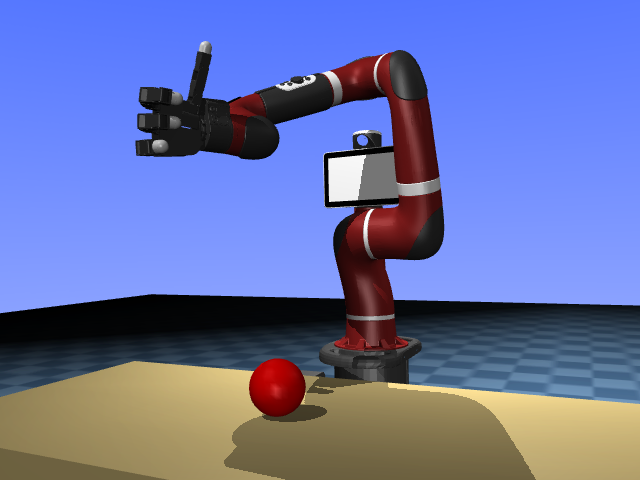

In [11]:
# Task 1:

## Debug flag
DEBUG_T1 = True

from multifingered_ik import LevenbergMarquardtIK

def evaluate_IK(physics, target_positions, target_orientations, target_names):
    """
    This function evaluates the IK solver for the target bodies.
    """
    model = physics.model
    data = physics.data
    step_size = 0.25
    tol = 0.002
    alpha = 0.5
    n = len(target_positions)
    jacp = np.zeros((n, 3, model.nv)) # translational Jacobian
    jacr = np.zeros((n, 3, model.nv)) # rotational Jacobian
    damping = 0.15
    max_steps = 200
    # max_steps = 10     # [MT]

    ik = LevenbergMarquardtIK(model, data, step_size, tol, alpha, jacp, jacr, damping, max_steps, physics)
    final_qpos = ik.calculate(target_positions, target_orientations, target_names)
    return final_qpos

# YOUR CODE HERE: Fill these in from lab doc
target_positions = [[1.0139, -0.4455, 1.4342], [1.0566, -0.3681, 1.4689], [1.0564, -0.3731, 1.4255], [1.0765, -0.3651, 1.3784], [0.9403, -0.4003, 1.6041]]
target_orientations = [[-0.62, -0.588, -0.3918, -0.3287], [0.3301, 0.305, -0.6762, -0.5838], [0.3465, 0.2863, -0.6522, -0.6104], [0.0174, -0.0705, -0.7239, -0.686], [-0.9672, 0.061, 0.0294, 0.2446]]
target_names = ['sawyer/allegro_right/palm', 'sawyer/allegro_right/ff_tip_rubber', 'sawyer/allegro_right/mf_tip_rubber', 'sawyer/allegro_right/rf_tip_rubber', 'sawyer/allegro_right/th_tip_rubber']

physics.reset() # 
final_qpos = evaluate_IK(physics, target_positions, target_orientations, target_names)


if DEBUG_T1:
    print(final_qpos) 

physics.data.qpos[:] = final_qpos
physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

In [12]:
# check desired position
target_pos = ball_body.pos.copy()
target_pos[2] += 0.1
print(ball_body.pos)
print(target_pos)

[ 1.   -0.2   0.95]
[ 1.   -0.2   1.05]


final pos of 0 is:  [ 1.001 -0.2    1.041]
final ori of 0 is:  [ 0.706  0.     0.708 -0.   ]
final error is:  0.001978967130221644
number of iterations:  54


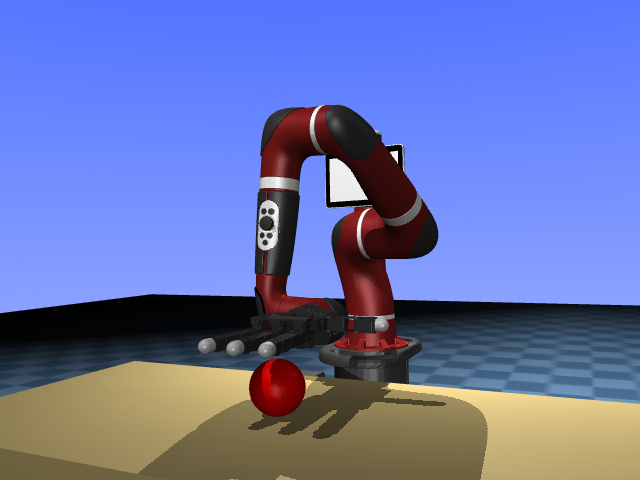

In [13]:
# Task 2:
# Note: your solution to task 1 must be correct for this starter code to work

# dz_height = 0.14
dz_height = 0.09

# Setting up initial hand configuration for grasp
physics.reset()
# Set palm target state
target_palm_position = ball_body.pos.copy() # [MT]: need to make a copy to avoid inplace update
target_palm_position[2] += dz_height
target_palm_position = target_palm_position.reshape(1, -1)
target_palm_orientation = np.array([[0.71, 0, 0.71, 0]])
target_name = ['sawyer/allegro_right/palm']

# Solve IK on palm
set_initial_configuration()
palm_qpos_IK = evaluate_IK(physics, target_palm_position, target_palm_orientation, target_name)
physics.data.qpos = palm_qpos_IK
physics.data.qpos[14:] = 0
physics.forward()
# PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id2))
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

(1000, 3)
(3, 1000)


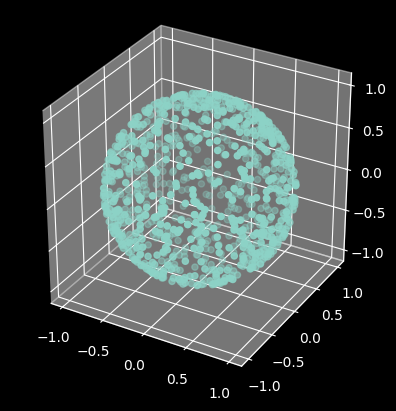

In [14]:
from utils import sampleRandomPointOnHypersphere

tmp = sampleRandomPointOnHypersphere(dim=3, num_pts=1000)

print(tmp.shape)
print(tmp.T.shape)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(tmp[:,0], tmp[:,1], tmp[:,2])
ax.set_aspect('equal', 'box')

In [ ]:
from AllegroHandEnv import AllegroHandEnvSphere
from grasp_synthesis import synthesize_grasp
# from grasp_synthesis import optimize_joint_space [MT]: comment out

# Run grasp synthesis algorithm to generate force closure hand configuration
q_h_slice = slice(14, 30)
q_h_init = physics.data.qpos[q_h_slice]
object_name = 'ball/ball_geom'
ball_radius = ball_geom.size[0]
ball_center = np.array(ball_body.pos)

allegro_env = AllegroHandEnvSphere(physics, ball_center, ball_radius, q_h_slice, object_name)
fingertip_names = ['sawyer/allegro_right/ff_tip_rubber', 'sawyer/allegro_right/mf_tip_rubber', 'sawyer/allegro_right/rf_tip_rubber', 'sawyer/allegro_right/th_tip_rubber']
# force_closure_q_h, first_contact_q_h = optimize_joint_space(allegro_env, q_h_init, fingertip_names) # original call
lr = 0.1 # 0.4
force_closure_q_h = synthesize_grasp(allegro_env, q_h_init, fingertip_names, lr=lr) # [MT]

Iter 0, objective=0.6331734, improvement=0.0793102
Iter 1, objective=0.6155530, improvement=0.0176203
Iter 2, objective=0.5979852, improvement=0.0175678
Iter 3, objective=0.5804932, improvement=0.0174920
Iter 4, objective=0.5631001, improvement=0.0173931
Iter 5, objective=0.5458283, improvement=0.0172717
Iter 6, objective=0.5287000, improvement=0.0171284
Iter 7, objective=0.5117363, improvement=0.0169637
Iter 8, objective=0.4949579, improvement=0.0167784
Iter 9, objective=0.4783845, improvement=0.0165734
Iter 10, objective=0.4620348, improvement=0.0163497
Iter 11, objective=0.4459267, improvement=0.0161081
Iter 12, objective=0.4300768, improvement=0.0158499
Iter 13, objective=0.4145007, improvement=0.0155761
Iter 14, objective=0.3992129, improvement=0.0152878
Iter 15, objective=0.3842266, improvement=0.0149863
Iter 16, objective=0.3695538, improvement=0.0146728
Iter 17, objective=0.3552053, improvement=0.0143485
Iter 18, objective=0.3411906, improvement=0.0140147
Iter 19, objective=0.3

In [ ]:
ncon = None
force = None
forcetorque = np.zeros(6)
total_force = 0


for j in range(physics.data.ncon):
    mj.mj_contactForce(physics.model.ptr, physics.data.ptr, j, forcetorque)
    total_force += forcetorque[:3]
    print(forcetorque)

print(physics.data.ncon)
print(forcetorque)
print(total_force)


[ 167.111  -15.566 -220.921    0.       0.       0.   ]
[ 139.16  -198.393   64.906    0.       0.       0.   ]
[ 74.883  28.86  108.553   0.      0.      0.   ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[ 96.612 125.004 -73.316   0.      0.      0.   ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[ 9.878 14.154 -4.383  0.     0.     0.   ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[  76.398 -108.822   35.921    0.       0.       0.   ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[ 209.686   89.148 -189.791    0.       0.       0.   ]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]
24
[0. 0. 0. 0. 0. 0.]
[ 773.728  -65.613 -279.031]


### Attempt 1: start from the force closure config and lift up

In [ ]:
## Step 1: compute the final palm position
physics.reset()

# define the amuont above to lift
lift_dz = 0.2

# Set palm target state
target_palm_position = ball_body.pos.copy() # [MT]: need to make a copy to avoid inplace update
target_palm_position[2] += lift_dz
target_palm_position = target_palm_position.reshape(1, -1)
target_palm_orientation = np.array([[0.71, 0, 0.71, 0]])
target_name = ['sawyer/allegro_right/palm']

# Solve IK on palm
set_initial_configuration()
# physics.data.qpos[q_h_slice] = force_closure_q_h # [MT]
palm_qpos_IK_end = evaluate_IK(physics, target_palm_position, target_palm_orientation, target_name)
# extract the parts related to the final palm: 7 ball + 7 palm + 16 fingers
qpos_palm_final = palm_qpos_IK_end[7:14].copy() # make a copy of it


final pos of 0 is:  [ 1.    -0.199  1.149]
final ori of 0 is:  [ 0.707  0.     0.707 -0.001]
final error is:  0.0018996570228918203
number of iterations:  52


final pos of 0 is:  [ 1.001 -0.2    1.041]
final ori of 0 is:  [ 0.706  0.     0.708 -0.   ]
final error is:  0.001978967130221675
number of iterations:  54


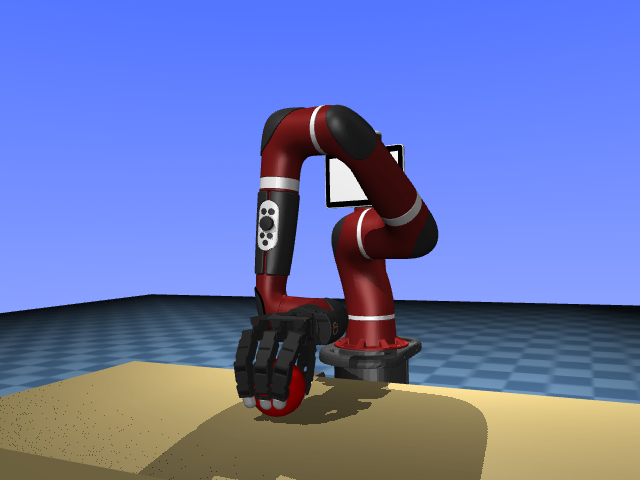

In [ ]:
## Step 2: re-compute the joint config for the initial condition

# dz_height = 0.14
dz_height = 0.09

# Setting up initial hand configuration for grasp
physics.reset()
# Set palm target state
target_palm_position = ball_body.pos.copy() # [MT]: need to make a copy to avoid inplace update
target_palm_position[2] += dz_height
target_palm_position = target_palm_position.reshape(1, -1)
target_palm_orientation = np.array([[0.71, 0, 0.71, 0]])
target_name = ['sawyer/allegro_right/palm']

# Solve IK on palm
set_initial_configuration()
# physics.data.qpos[q_h_slice] = force_closure_q_h # [MT]
palm_qpos_IK = evaluate_IK(physics, target_palm_position, target_palm_orientation, target_name)
physics.data.qpos = palm_qpos_IK
physics.data.qpos[14:] = force_closure_q_h  # using the force closure grasp as the starting point

# extract the part related to the initial palm: 7 ball + 7 palm + 16 fingers
qpos_palm_init = palm_qpos_IK[7:14].copy() # make a copy of it

# show the initial configuration
physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))




In [ ]:
print(qpos_palm_init)
print(qpos_palm_final)

[-0.183 -0.564 -0.052  2.053 -0.211 -1.497  3.376]
[-0.172 -0.89  -0.065  2.15  -0.23  -1.277  3.425]


This browser does not support the video tag.


Text(0, 0.5, 'Newton')

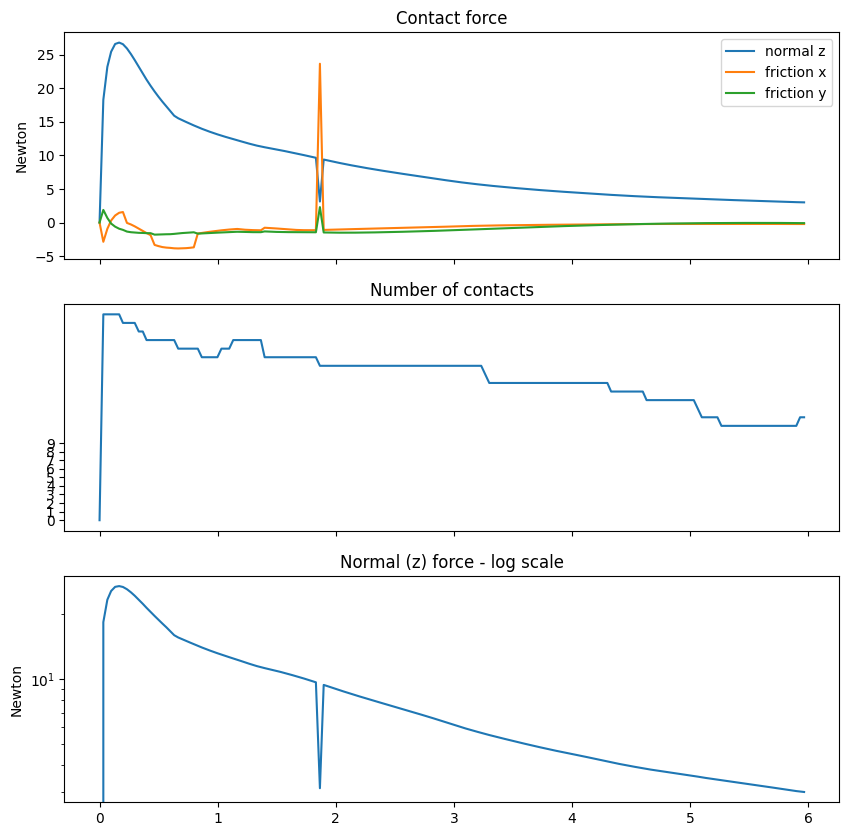

In [ ]:
# Lift-from-grasp video + plots
duration = 6
framerate = 30
n_steps = duration * framerate
video = []

# define the variables to store information
sim_time = np.zeros(n_steps)
ncon = np.zeros(n_steps)
force = np.zeros((n_steps, 3))
forcetorque = np.zeros(6)

# make a copy of the starting configuration
start_config = physics.data.qpos[:].copy()

# Here are some flags you can set to visualize contact forces
# We suggest that you visualize the results of your grasp synthesis algorithm when debugging
# Visualize contact frames and forces, make body transparent
options = mj.MjvOption()
mj.mjv_defaultOption(options)
options.flags[mj.mjtVisFlag.mjVIS_CONTACTPOINT] = False
options.flags[mj.mjtVisFlag.mjVIS_CONTACTFORCE] = False
options.flags[mj.mjtVisFlag.mjVIS_TRANSPARENT] = False

# Run control loop
with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for i in range(n_steps):

        t = i / framerate

        while physics.data.time * framerate < i:
            # Control robot and collect data for plotting
            #YOUR CODE HERE
            # Phase 1: move from initial config to final config
            if t < 4.0:
                tau = t / 4.0
                q_target = (1 - tau) * qpos_palm_init + tau * qpos_palm_final
                start_config[7:14] = q_target
            # Phase 2: hold lifted pose
            else:
                pass
            # Control robot only, not the free ball joint
            physics.set_control(start_config[7:])
            sim_time[i] = physics.data.time
            ncon[i] = physics.data.ncon
            total_force = np.zeros(3)
            for j in range(physics.data.ncon):
                mj.mj_contactForce(physics.model.ptr, physics.data.ptr, j, forcetorque)
                total_force += forcetorque[:3]
            force[i] = total_force
            physics.step()
        # Render scene, feel free to change camera
        # renderer.update_scene(physics.data.ptr, "camera_2", options) # original
        renderer.update_scene(physics.data.ptr, "camera_1", options)
        frame = renderer.render()
        video.append(frame)

# Show video
media.show_video(video, fps=framerate)

# Plot
# This is just to serve as an example for plotting. You'll likely have to make some changes for the deliverables
_, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

lines = ax[0].plot(sim_time, force)
ax[0].set_title('Contact force')
ax[0].set_ylabel('Newton')
ax[0].legend(list(lines), ('normal z', 'friction x', 'friction y'))
ax[1].plot(sim_time, ncon)
ax[1].set_title('Number of contacts')
ax[1].set_yticks(range(10))

ax[2].plot(sim_time, force[:,0])
ax[2].set_yscale('log')
ax[2].set_title('Normal (z) force - log scale')
ax[2].set_ylabel('Newton')


In [ ]:
import mediapy as media
output_path = "main_task2_baseline_video.mp4"
media.write_video(output_path, video, fps=framerate)
print(f"Saved video to {output_path}")

Saved video to main_task2_baseline_video.mp4
